# Koduppgift kapitel 1, uppgift 11
### I koden nedan använder vi först test_size=0.2 och sedan test_size=0.25, förklara varför det ger oss proportionerna 60-20-20.

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

"""
I första blocket gör vi fördelningen mellan träningsdata och testdata och bestämmer att fördelningen ska vara 20% till test, vilket innebär 80% till träning.

I andra blocket bestämmer vi att 25% av träningssetet som precis skapats ska vara valideringsdata. Detta innebär 80% x 25% = 20% till validering. Nu återstår alltså 60% till träning.
"""


# Koduppgifter kapitel 2, uppgift 8-12

# 2.8
### Förklara vad koden nedan gör. Varför är det viktigt att kunna spara en modell?

In [ ]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from joblib import dump, load
X, y = make_regression(n_samples=20000, n_features=3, noise=0.1)
model = LinearRegression().fit(X, y)
dump(model, "linear_model.joblib")
model_loaded = load("linear_model.joblib")
print(model_loaded.predict(X[:5]))

Svar: Koden skapar ett dataset, skapar och tränar en linjär regressionsmodell och sparar den som en joblib-fil (dump från joblib) och sedan laddas filen (load från joblib) för att genomföra prediktioner.

Det är viktigt att kunna spara en modell av samma anledning som det är viktigt att kunna spara vilken fil, skript eller program som helst - för att kunna använda den igen. Modellträning kan vara tids och prestandakrävande, när vi sparar en tränad modell och laddar den på nytt får vi den tränad och klar.

------------------------------

# 2.9
### Denna uppgift består av flera steg enligt nedan.

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
import pandas as pd

# a) Läs in datasetet “data_01.csv” med funktionen read_csv() från Pandas. Funktionen returnerar en DataFrame.
df = pd.read_csv('data_01.csv')

# b) Dela upp datasetet i X och y.
X = df.drop(columns=['target'])
y = df['target']

# c) Dela upp datan ytterligare, i ett träning-, ett validering-, och ett testset med train_test_split(). Låt 20% av datan vara testdata och 15% av den återstående datan vara valideringsdata.
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

# d) Träna två valfria regressionsmodeller (exempelvis LinearRegression och DecisionTreeRegressor) på träningsdatan. Notera, i kapitel 3 kommer vi lära oss mer om DecisionTreeRegressor.

## Model 1 - Linear regression
model_reg = LinearRegression()
model_reg.fit(X_train, y_train)

## Model 2 - Decision Tree Regressor
model_dtr = DecisionTreeRegressor(random_state=42)
model_dtr.fit(X_train, y_train)

# e) Utvärdera modellerna på valideringsdatan.
y_val_pred_reg = model_reg.predict(X_val)
y_val_pred_dtr = model_dtr.predict(X_val)

print(f'Linear regression model RMSE: {root_mean_squared_error(y_val, y_val_pred_reg)}')
print(f'Decision tree regressor model RMSE: {root_mean_squared_error(y_val, y_val_pred_dtr)}')

Linear regression model RMSE: 3.592300959691065
Decision tree regressor model RMSE: 99.3594190386419


In [2]:
# f) Träna om den bäst presterande modellen på både tränings- och valideringsdatan.
model_reg.fit(X_train_full, y_train_full)

# g) Utvärdera modellen på testdatan.
y_test_pred_reg = model_reg.predict(X_test)
r2_score = model_reg.score(X_test, y_test)
print(f'RMSE: {root_mean_squared_error(y_test, y_test_pred_reg)}')
print(f'R2 score: {r2_score}')

# h) Träna om modellen på hela datasetet.
final_model_reg = model_reg.fit(X, y)

RMSE: 3.371549077515551
R2 score: 0.9991205203171207


-------------------------------------

# 2.10
### Datasetet “salary_dataset.csv” innehåller 29 observationer av personer.Years Experience är hur många år de arbetat, och Salary är deras lön.

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor

# a) Läs in datasetet “salary_dataset.csv” med pandas read_csv()-funktion och dela upp i X och y. Avgör själv vilken variabel som ska vara den beroende variabeln y.

df_salary = pd.read_csv('salary_dataset.csv')
X = df_salary.drop(columns=['Salary'])
y = df_salary['Salary']

# b) Dela upp datasetet i träning- och testset. (Inget validerings-set alltså!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# c) Träna två regressionsmodeller med k-delad korsvalidering med cross_validate()-funktionen från scikit-learn. Använd neg_root_mean_squared_error som scoring. Välj själv hur många iterationer den ska göra genom hyperparametern cv.

## Model 1 - Linear regression
model_reg = LinearRegression()
cv_reg = cross_validate(
    model_reg,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_reg = -(cv_reg['test_score'].mean())

print(f"Linear regression RMSE: {rmse_reg}")

## Model 2 - Decision Tree Regressor
model_dtr = DecisionTreeRegressor(random_state=42)
cv_dtr = cross_validate(
    model_dtr,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_dtr = -(cv_dtr['test_score'].mean())

print(f"Decision Tree Regressor RMSE: {rmse_dtr}")

# d) Utvärdera modellen som presterar bäst på testsetet.
if rmse_dtr < rmse_reg:
    best_model = model_dtr
    print(f"Best model: Decision Tree Regressor")
else:
    best_model = model_reg
    print(f"Best model: Linear Regression")

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred)}")

Linear regression RMSE: 5293.203196998775
Decision Tree Regressor RMSE: 5611.57858424216
Best model: Linear Regression
Test RMSE: 7059.043621901506


--------------------------------------------

# 2.11
### I denna uppgift kommer vi arbeta med kategorisk data. Nominaldata är kategorisk data där kategorierna inte har någon inbördes rangordning.

### Datasetet mpg som följer med biblioteket seaborn är ett dataset med 398 observationer av bilar. Den beroende variabeln mpg står för miles per gallon och beskriver bilarnas bränsleeffektivitet.

### Om vi vill träna en regressionsmodell på mpg-datasetet behöver vi hantera de två kategoriska variablerna origin och name. Variabeln origin är en kategorisk variabel med tre olika värden: europe, japan och usa. Den lämpar sig bra för one hot encoding. Variabeln name har 305 unika värden. Skulle vi utföra one hot encoding på den skulle vårt dataset få 305 nya dimensioner vilket inte är så lämpligt i detta fall. Dessutom - tror du att namnet på bilen har något att göra med hur långt den kör på en gallon bensin? Vi ska därför droppa name-kolumnen innan vi börjar träna en modell på datan.

In [74]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

# a) Läs in datasetet mpg med seaborns load_dataset()-funktion (det gjordes i koden ovan).
df = sns.load_dataset("mpg")

# b) Droppa rader med saknade värden med dropna()-metoden
df_dropna = df.dropna()

# c) Droppa kolumnen name.
df_dropname = df_dropna.drop(columns=['name'])

# d) Utför en dummy-variable-encoding på origin-kolumnen med pandas get_dummies()-funktion. Ange drop_first=True så att vi får 2 nya kolumner istället för 3.
df_dummy = pd.get_dummies(df_dropname, columns=['origin'], dtype= int, drop_first=True)

# e) Dela upp datasetet i X och y, med mpg som den beroende variabeln y.
X = df_dummy.drop(columns=['mpg'])
y = df_dummy['mpg']

# f) Dela upp datasetet i träning- och testset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# g) Träna en linjär regressionsmodell på träningsdatan och utvärdera den på testdatan.
model_reg = LinearRegression()
model_reg.fit(X_train, y_train)

y_pred = model_reg.predict(X_test)
print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred)}")

Test RMSE: 3.256114096847396


-----------------------------------------------

# 2.12
### I avsnitt 2.2 “Ett kodexempel från början till slut - Huspriser i Kalifornien” så gås ett komplett kodexempel igenom. På valideringsdatan fick vi RMSE Random Forest Regression: 52277.96578719621. Försök få ett bättre resultat genom att exempelvis justera hyperparametrar eller genomföra variabelselektion.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
import pandas as pd

# Importing dataset
df_house = pd.read_csv('housing.csv')

# Feature engineering

# Cleaning
df = df_house.dropna()
df = df[df['ocean_proximity'] != 'ISLAND']
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype= int, drop_first=True)

# Defining feature and target columns
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

# Train, val, test split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train/val
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

# Choosing models
## Model 1 - Linear regression
model_reg = LinearRegression()
model_reg.fit(X_train, y_train)

## Model 2 - Random forest regressor
model = RandomForestRegressor(
    max_depth=None,
    max_features='sqrt',
    random_state=42)

### Grid Search - Hyperparameters
### First run: n_est: 300, max_depth: None, min_sample_leafs: 1, max_features: sqrt, min_sample_split: 2
### Second run: n_est: 400
param_grid = {
    "n_estimators": [400]
}

### Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
best_rmse = -grid_search.best_score_
print("Best Random forest regressor RMSE:", best_rmse)

best_rfr_model = grid_search.best_estimator_

Best parameters: {'n_estimators': 400}
Best Random forest regressor RMSE: 50605.246322423685


In [8]:
from sklearn.metrics import root_mean_squared_error
# Validation
y_pred_reg = model_reg.predict(X_val)
print(f"Validation Linear Regression RMSE: {root_mean_squared_error(y_val, y_pred_reg)}")

y_pred_rfr = best_rfr_model.predict(X_val)
print(f"Validation Random forest regressor RMSE: {root_mean_squared_error(y_val, y_pred_rfr)}")

best_rfr_model.fit(X_train_full, y_train_full)
print('Model retrained on full training set')

Validation Linear Regression RMSE: 69343.34670700814
Validation Random forest regressor RMSE: 50830.436773233574
Model retrained on full training set


In [9]:
y_test_pred = best_rfr_model.predict(X_test)
print(f"Test Random forest regressor RMSE: {root_mean_squared_error(y_test, y_test_pred)}")

Test Random forest regressor RMSE: 48958.46419129263


----------------------------

# Kapitel 3, uppgift 13-16

# 3.13
### Datasetet “hr_employee_data.xlsx” innehåller data kopplat till ett företags anställda. Gör en EDA och tillhörande analys, föreställ dig att ledningsgruppen på ett företag ska ta del av analysen. I denna uppgift ska ingen ML-modellering göras (det kommer göras i nästa kapitel). Syftet är dels att träna på att genomföra analyser dels att demonstrera hur mycket man kan göra även utan ML-modellering.

In [14]:
import pandas as pd
import numpy as np
# Dataframe
df_hr = pd.read_excel("hr_employee_data.xlsx")
print(df_hr.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  object 
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  object 
 10  salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(3)
memory usage: 1.3+ MB
None


In [15]:
print(df_hr.describe())

       satisfaction_level  last_evaluation  number_project  \
count        14999.000000     14999.000000    14999.000000   
mean             0.612834         0.716102        3.803054   
std              0.248631         0.171169        1.232592   
min              0.090000         0.360000        2.000000   
25%              0.440000         0.560000        3.000000   
50%              0.640000         0.720000        4.000000   
75%              0.820000         0.870000        5.000000   
max              1.000000         1.000000        7.000000   

       average_montly_hours  time_spend_company  Work_accident          left  \
count          14999.000000        14999.000000   14999.000000  14999.000000   
mean             201.050337            3.498233       0.144610      0.238083   
std               49.943099            1.460136       0.351719      0.425924   
min               96.000000            2.000000       0.000000      0.000000   
25%              156.000000            3.

In [16]:
"""
Findings from descriptive stats:
- The average satisfaction level has decreased by approximately 10% since last evaluation.
- There is also greater variability (standard deviation) compared to the previous evaluation. This change may be due to more people being less satisfied.
- The average number of hours worked per month is 201 (around 50 h/week), and 25% of employees work more than 245 h/month.
"""

# Checking satisfaction level department by department
print(
    df_hr.groupby('Department').agg(
        mean_satisfaction_level=('satisfaction_level', 'mean'),
        employee_count=('Emp_Id', 'count')
    ).sort_values(by='mean_satisfaction_level').round(2)
)

             mean_satisfaction_level  employee_count
Department                                          
accounting                      0.58             767
hr                              0.60             739
technical                       0.61            2720
sales                           0.61            4140
IT                              0.62            1227
support                         0.62            2229
marketing                       0.62             858
product_mng                     0.62             902
RandD                           0.62             787
management                      0.62             630


In [18]:
"""
Findings:
- Lowest mean satisfaction level is in accounting
- Highest mean satisfaction level is in management
"""

# Checkning correlation between satisfaction level and other variables
## Creating dummies for dept, salary etc.
df_dummies_prep = df_hr.drop(columns=['Emp_Id'])
df_dummies = pd.get_dummies(df_dummies_prep)

## Extracting variable names, calculating correlation with pandas .corr()
df_variables = [i for i in df_dummies.columns if i != 'satisfaction_level']
dict_corr = {}
for variable in df_variables:
    correlation = df_dummies['satisfaction_level'].corr(df_dummies[variable])
    dict_corr[variable] = float(correlation)

## Printing top 10 absolute correlation values
df_corr = pd.DataFrame(list(dict_corr.items()), columns=['variable', 'correlation'])
df_corr['corr_abs'] = df_corr.correlation.abs()
df_corr = df_corr.sort_values(by=['corr_abs'], ascending=False)
print(df_corr.head(10))

                 variable  correlation  corr_abs
5                    left    -0.388375  0.388375
1          number_project    -0.142970  0.142970
0         last_evaluation     0.105021  0.105021
3      time_spend_company    -0.100866  0.100866
4           Work_accident     0.058697  0.058697
18             salary_low    -0.047415  0.047415
19          salary_medium     0.031367  0.031367
17            salary_high     0.029708  0.029708
9   Department_accounting    -0.028649  0.028649
6   promotion_last_5years     0.025605  0.025605


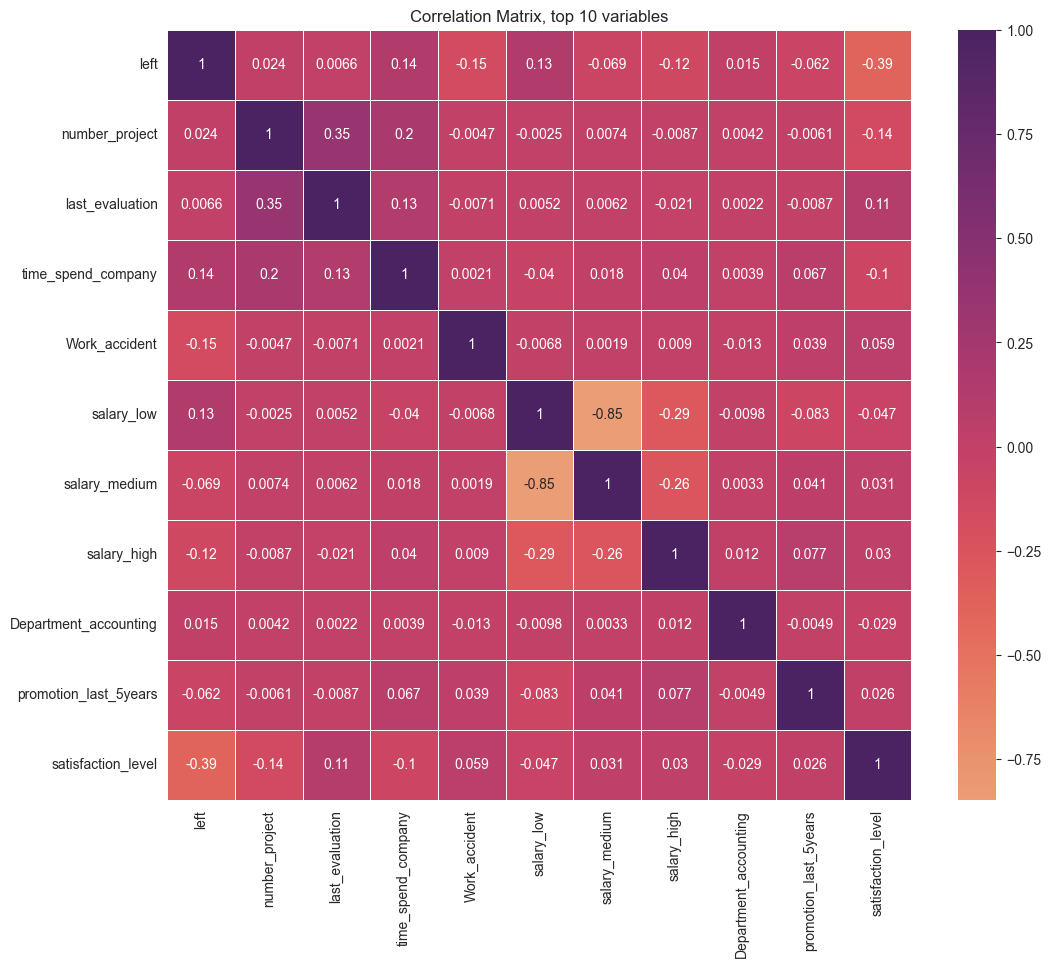

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creating a correlation matrix
## Focusing on top 10 values
picked_variables = [var for var in df_corr['variable'].head(10)]
picked_variables.append('satisfaction_level')
df_matrix = df_dummies[picked_variables]

# The actual matrix
corr_matrix = df_matrix.corr()

# Plotting in heat map
plt.figure(figsize=(12,10))
cmap = sns.color_palette("flare", as_cmap=True)
sns.heatmap(
    corr_matrix,
    annot=True,
    center=0,
    cmap=cmap,
    linewidths=0.5
)

plt.title('Correlation Matrix, top 10 variables')
plt.show()

                employee_count  satisfaction_level
number_project                                    
2                         2388            0.478769
3                         4055            0.687670
4                         4365            0.695132
5                         2761            0.678888
6                         1174            0.273458
7                          256            0.118711


Text(0.5, 1.0, 'Satisfaction x Project Workload')

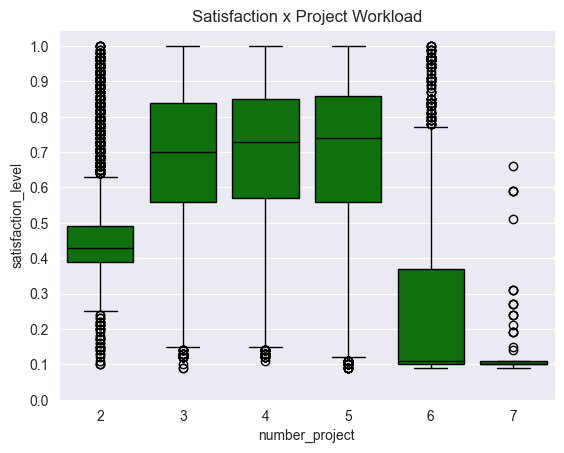

In [24]:
"""
Findings:
- The negative correlation between leaving the company and satisfaction is no surprise...
- Also seems like there is a small correlation between number of projects and satisfaction level
"""

# Let's take a look at the relationship between number of projects and satisfaction level.
print(df_hr.groupby('number_project').agg(
    employee_count=('Emp_Id', 'count'),
    satisfaction_level=('satisfaction_level', 'mean')
))
sns.boxplot(data=df_hr,
            x='number_project',
            y='satisfaction_level',
            color='green',
            linecolor='black')

plt.yticks(np.arange(0, 1.1, 0.1))
plt.title('Satisfaction x Project Workload')


# Key findings and recommendation for management

There is a clear relationship between workload (number of projects) and employee satisfaction:

*Low workload (2 projects):*
Employees appear to be under-stimulated. Approximately 75% of the 2,388 employees in this group have a satisfaction level between 40% and 50% (roughly).

*High workload (6–7 projects):*
Employees in this group show lower satisfaction levels, and a potential risk of burnout.
- For employees with 7 projects (256 employees), satisfaction levels are clustered around ~10%
- For employees with 6 projects (1,174 employees), satisfaction levels range roughly between 10% and 35%.

Recommended actions:
- Use machine learning models to identify employees at risk of leaving
 - Build a management dashboard with recommendations on how to up employee satisfaction.

Employees leaving = money bleeding. Research indicates that replacing an employee can cost between 65% and 100% of their annual salary.

-----------------------------------------------

# 3.14
### Nedan ser vi en början till modellering av ett dataset kopplat till diabetes. Läs på vad datasetet innebär och genomför ett komplett ML-flöde. Börja med att göra ett grundläggande flöde som fungerar, därefter kan du om du önskar försöka förbättra resultatet.


In [116]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, root_mean_squared_error

# This code is merely executed to see the description of the data in a smooth way
data = load_diabetes()
#print(data.DESCR)
# Storing/loading the data the way it will be used
X, y = load_diabetes(return_X_y=True, as_frame=True)
#print(X.info())
#print(y.info())
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# Instantiating and training
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

model_ridge = Ridge()
model_ridge.fit(X_train, y_train)

model_lasso = Lasso()
model_lasso.fit(X_train, y_train)

model_elasticnet = ElasticNet()
model_elasticnet.fit(X_train, y_train)

# Evaluation - off the shelf
y_lr_pred = model_lr.predict(X_val)
y_ridge_pred = model_ridge.predict(X_val)
y_lasso_pred = model_lasso.predict(X_val)
y_elasticnet_pred = model_elasticnet.predict(X_val)

# RMSE scores
lr_score = root_mean_squared_error(y_val, y_lr_pred)
ridge_score = root_mean_squared_error(y_val, y_ridge_pred)
lasso_score = root_mean_squared_error(y_val, y_lasso_pred)
elasticnet_score = root_mean_squared_error(y_val, y_elasticnet_pred)

# R2 scores
linear_r2_score = r2_score(y_val, y_lr_pred)
ridge_r2_score = r2_score(y_val, y_ridge_pred)
lasso_r2_score = r2_score(y_val, y_lasso_pred)
elasticnet_r2_score = r2_score(y_val, y_elasticnet_pred)

print(f"RMSE SCORE PER MODEL:\n"
      f"Linear Regression: {lr_score}\n"
      f"Ridge:             {ridge_score}\n"
      f"Lasso:             {lasso_score}\n"
      f"Elastic Net:       {elasticnet_score}")
print('------------------------------------------')
print(f"R2 SCORE PER MODEL:\n"
      f"Linear Regression: {linear_r2_score}\n"
      f"Ridge:             {ridge_r2_score}\n"
      f"Lasso:             {lasso_r2_score}\n"
      f"Elastic Net:       {elasticnet_r2_score}")

RMSE SCORE PER MODEL:
Linear Regression: 53.37368921191778
Ridge:             56.706469058733354
Lasso:             60.228450260255364
Elastic Net:       75.54891172613722
------------------------------------------
R2 SCORE PER MODEL:
Linear Regression: 0.4701254773149868
Ridge:             0.4018862241352811
Lasso:             0.3252825063927086
Elastic Net:       -0.0616344891804419


In [119]:
from sklearn.model_selection import GridSearchCV

# Grid Search
ridge_lasso_params = {
    'alpha' : [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
elasticnet_params = {
    'alpha' : [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'l1_ratio' : [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_search_ridge = GridSearchCV(
    estimator=model_ridge,
    param_grid=ridge_lasso_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search_lasso = GridSearchCV(
    estimator=model_lasso,
    param_grid=ridge_lasso_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search_elasticnet = GridSearchCV(
    estimator=model_elasticnet,
    param_grid=elasticnet_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search_ridge.fit(X_train, y_train)
best_ridge = grid_search_ridge.best_score_
print("Best Ridge regression R2:", best_ridge)
print('-----------------------------------------------')
grid_search_lasso.fit(X_train, y_train)
best_lasso = grid_search_lasso.best_score_
print("Best Lasso regression R2:", best_lasso)
print('-----------------------------------------------')
grid_search_elasticnet.fit(X_train, y_train)
best_elasticnet = grid_search_elasticnet.best_score_
print("Best Elasticnet regression R2:", best_elasticnet)

Best Ridge regression R2: 0.4736126646494208
-----------------------------------------------
Best Lasso regression R2: 0.47023066778085304
-----------------------------------------------
Best Elasticnet regression R2: 0.47366379121203417


In [123]:
best_ridge_model = grid_search_ridge.best_estimator_
best_lasso_model = grid_search_lasso.best_estimator_
best_elastic_model = grid_search_elasticnet.best_estimator_

y_pred_ridge = best_ridge_model.predict(X_val)
y_pred_lasso = best_lasso_model.predict(X_val)
y_pred_elastic = best_elastic_model.predict(X_val)

# RMSE Score
ridge_rmse = root_mean_squared_error(y_val, y_pred_ridge)
lasso_rmse = root_mean_squared_error(y_val, y_pred_lasso)
elastic_rmse = root_mean_squared_error(y_val, y_pred_elastic)

# R2 score
ridge_r2 = r2_score(y_val, y_pred_ridge)
lasso_r2 = r2_score(y_val, y_pred_lasso)
elastic_r2 = r2_score(y_val, y_pred_elastic)

print(f"RMSE SCORE PER MODEL:\n"
      f"Linear Regression: {lr_score}\n"
      f"Ridge:             {ridge_rmse}\n"
      f"Lasso:             {lasso_rmse}\n"
      f"Elastic Net:       {elastic_rmse}")
print('------------------------------------------')
print(f"R2 SCORE PER MODEL:\n"
      f"Linear Regression: {linear_r2_score}\n"
      f"Ridge:             {ridge_r2}\n"
      f"Lasso:             {lasso_r2}\n"
      f"Elastic Net:       {elastic_r2}")

RMSE SCORE PER MODEL:
Linear Regression: 53.37368921191778
Ridge:             53.415730165714834
Lasso:             53.5007218243981
Elastic Net:       53.42180562313483
------------------------------------------
R2 SCORE PER MODEL:
Linear Regression: 0.4701254773149868
Ridge:             0.46929041405013483
Lasso:             0.46760020883768916
Elastic Net:       0.46916968231637335


In [127]:
# Best model is Linear Regression model
# Training on full training data set
model_lr.fit(X_train_full, y_train_full)

# Predicting test data
y_pred_test = model_lr.predict(X_test)

# RMSE and R2 Score
test_rmse = root_mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)


print(f"FINAL TEST SCORE, LINEAR REGRESSION MODEL \n"
      f"RMSE: {test_rmse}\n"
      f"R2:   {test_r2}\n"
      )

# Training on whole data set
model_lr.fit(X, y)
print('Model trained')

FINAL TEST SCORE, LINEAR REGRESSION MODEL 
RMSE: 53.85344583676593
R2:   0.4526027629719195

Model trained


----------------------------------

# 3.15
### I denna uppgift ska vi arbeta med datasetet “car_price_dataset.csv”
### a) Gör ett komplett ML flöde där den beroende variabeln, 𝑦, är price. Vi vill alltså skapa en modell som kan prediktera en bils pris. Ett tips är att först göra ett enkelt flöde som fungerar, har du därefter tid kan du försöka förbättra resultaten.

In [90]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

df = pd.read_csv('car_price_dataset.csv', delimiter=';')

# Basic
## X, y
X_with_categorical = df.drop(columns=['Price'])
y = df['Price']

## Creating dummies for categorical data
X = pd.get_dummies(X_with_categorical)

## Train-Val-Test splitting
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

## Instantiating and training
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)

random_forest_model = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [400, 500, 600],
    'max_depth': [30, 40],
    'min_samples_split': [2],
    'min_samples_leaf': [2]
}
# First run: 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300 - score 0.984407
# Second run: 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400 - score 0.984453
# Third run: 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400 - score 0.984453

grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)


grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print('Best hyperparameters:')
print(best_params)
print("Best Random forest R2:", best_score)

Best hyperparameters:
{'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}
Best Random forest R2: 0.9844534122426731


In [91]:
best_forest_model = grid_search.best_estimator_

## Evaluating
y_linear_valpred = linear_regression_model.predict(X_val)
y_random_forest_valpred = best_forest_model.predict(X_val)

## Scores
linear_val_rmse = root_mean_squared_error(y_val, y_linear_valpred)
linear_r2 = r2_score(y_val, y_linear_valpred)

random_forest_rmse = root_mean_squared_error(y_val, y_random_forest_valpred)
random_forest_r2 = r2_score(y_val, y_random_forest_valpred)

print("Linear Regression RMSE:", linear_val_rmse)
print("Linear Regression R2:", linear_r2)
print("--------------------------------------------")
print("Random Forest RMSE:", random_forest_rmse)
print("Random Forest R2:", random_forest_r2)

Linear Regression RMSE: 63.635385861097774
Linear Regression R2: 0.9995807126990037
--------------------------------------------
Random Forest RMSE: 366.1168127656972
Random Forest R2: 0.9861211433128034


In [95]:
# Linear Regression is better - training on full train set
linear_regression_model.fit(X_train_full, y_train_full)

# Predicting test
y_pred_test = linear_regression_model.predict(X_test)

# Score
linear_test_rmse = root_mean_squared_error(y_test, y_pred_test)
linear_test_r2 = r2_score(y_test, y_pred_test)

print("Linear Regression RMSE:", linear_test_rmse)
print("Linear Regression R2:", linear_test_r2)

# Training on full set
linear_regression_model.fit(X, y)

# Exporting the model
import joblib

joblib.dump(linear_regression_model, 'car_price_linear_regression_model.pkl')
joblib.dump(X.columns, "model_columns.pkl")
print("Model saved!")

Linear Regression RMSE: 64.91473251756284
Linear Regression R2: 0.9995413573365225
Model saved!


### 3.15 b) Gör en applikation med hjälp av Streamlit där användaren kan mata in olika uppgifter om en bil och därefter få ett predikterat pris.

Se filen streamlit.py

In [45]:
# Om appen ligger i samma mapp borde det funka att köra denna cell
!streamlit run streamlit.py

^C


### 3.15 c) Det du gjort i denna uppgift, hade det kunnat användas i verkligheten? Till vad i sådana fall?

Det skulle kunna användas av en bilfirma som ska köpa in bilar, de kan snabbt slå upp en bils väntade marknadsvärde utifrån dessa variabler och sedan dra av en slant från budet de lämnar till säljaren.


---------------------------------

# 3.16
###  I denna uppgift ska du göra ett komplett ML-flöde där du modellerar diamantpriser som finns tillgängliga i datasetet “diamonds.csv”. Du kan läsa mer om datasetet här: https://www.kaggle.com/datasets/shivam2503/diamonds

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

df = pd.read_csv('diamonds.csv')

column_check = ['x', 'y', 'z']

for i in column_check:
    df = df[df[i] != 0]

## X, y
X_with_categorical = df.drop(columns=['price','Unnamed: 0'])
y = df['price']

## Creating dummies for categorical data
X = pd.get_dummies(X_with_categorical, drop_first=True)

## Train-Val-Test splitting
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

## Instantiating and training
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)
random_forest_model = RandomForestRegressor(random_state=42)

## Grid Search
rf_param_grid = {
    'n_estimators': [100, 400],
    'max_depth': [None, 20],
    'min_samples_split': [2,5],
    'min_samples_leaf': [2],
    'max_features': ['log2', 'sqrt']
}

rf_grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print('Best hyperparameters:')
print(rf_grid_search.best_params_)
print("Best Random forest R2:")
print(rf_grid_search.best_score_)

Best hyperparameters:
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}
Best Random forest R2:
0.964671892893876


In [30]:
best_rforest_model = rf_grid_search.best_estimator_

# Predict Val set
y_pred_val_linear = linear_regression_model.predict(X_val)
y_pred_val_rf = best_rforest_model.predict(X_val)

# Score
linear_rmse = root_mean_squared_error(y_val, y_pred_val_linear)
linear_r2 = r2_score(y_val, y_pred_val_linear)

rf_rmse = root_mean_squared_error(y_val, y_pred_val_rf)
rf_r2 = r2_score(y_val, y_pred_val_rf)

print("Linear RMSE:", linear_rmse)
print("Linear R2:", linear_r2)
print("Random forest Regressor RMSE:", rf_rmse)
print("Random forest Regressor R2:", rf_r2)

Linear RMSE: 1147.0183213144762
Linear R2: 0.9166004365130547
Random forest Regressor RMSE: 718.9452556159803
Random forest Regressor R2: 0.9672346575120736


In [31]:
# Best model is Random Forest
best_rforest_model.fit(X_train_full, y_train_full)

#best_forest_model = rf_grid_search.best_estimator_
y_pred_test_rf = best_rforest_model.predict(X_test)

# Score
rf_rmse = root_mean_squared_error(y_test, y_pred_test_rf)
rf_r2 = r2_score(y_test, y_pred_test_rf)

print("Random forest Regressor RMSE:", rf_rmse)
print("Random forest Regressor R2:", rf_r2)

Random forest Regressor RMSE: 666.3775470886613
Random forest Regressor R2: 0.972301621994737


In [ ]:
# Training on full X,y
best_rforest_model.fit(X,y)

------------------------------

# Kapitel 4, uppgift 11-15

# 4.11
### Förklara vad nedanstående kod gör och tolka resultatet från koden.

In [128]:
from sklearn.metrics import classification_report
y_true = [0, 1, 2, 2, 2]
y_pred = [0, 0, 2, 2, 1]
target_names = ['class 0', 'class 1', 'class 2']
print(classification_report(y_true, y_pred, target_names=target_names))

"""
Koden simulerar genomförda prediktioner av klasserna class 0, class 1 och class 2.

Den skriver även ut en classification report som jämför predikterade klasser med verkliga klasser. Rapporten visar att oviktat medelvärde för precision är 50% och att viktat är 70%. Anledningen till högre viktat värde är att det fanns fler observationer i class 2 där alla prediktioner på denna klass visade sig vara korrekta.

 Att vi endast fick 67% i recall på samma klass innebär att det finns ytterligare en observation som var class 2, vi hittade alltså två av tre i denna klass.

 f1-score för samma klass visar att det harmoniska medelvärdet mellan precision och recall var 80%.

 Av resultatet framgår även att accuracy var totalt 60%, det vill säga att 3 av totalt 5 prediktioner var korrekta.

"""

              precision    recall  f1-score   support

     class 0       0.50      1.00      0.67         1
     class 1       0.00      0.00      0.00         1
     class 2       1.00      0.67      0.80         3

    accuracy                           0.60         5
   macro avg       0.50      0.56      0.49         5
weighted avg       0.70      0.60      0.61         5



-------------------------------------

# 4.12
### Läs dokumentationen och visualisera ett beslutsträd: https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html

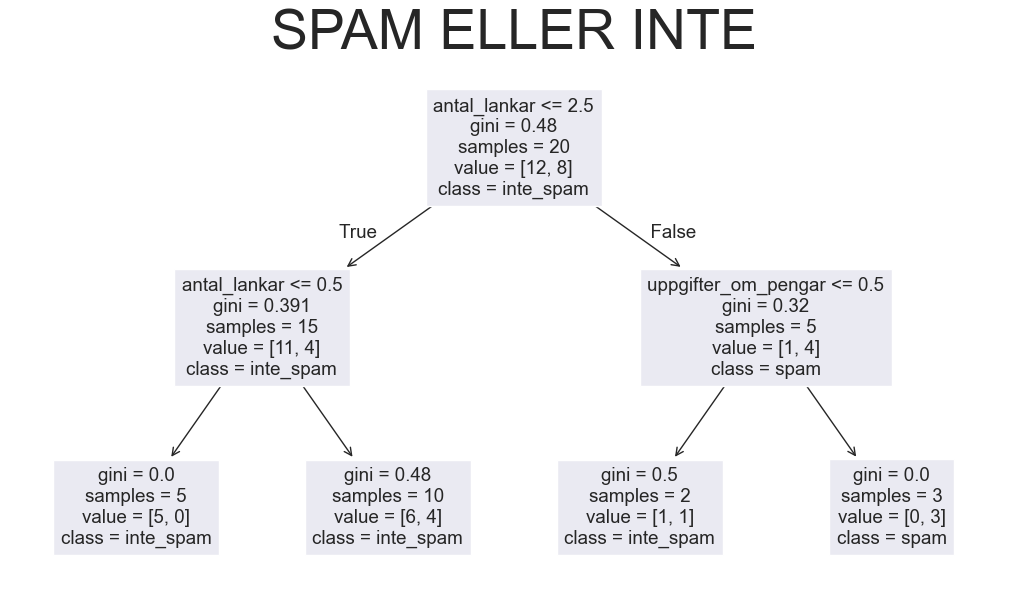

In [11]:
from sklearn import tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creating som random data
data = {
    "antal_lankar":         [0,0,0,0,0,1,1,1,1,1,2,2,2,2,2,3,3,4,4,3],
    "uppgifter_om_pengar":  [1,1,0,0,0,1,0,1,0,1,1,1,0,0,0,1,0,1,0,1],
    "spam":                 [0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,1,1]
}

df = pd.DataFrame(data)

# Defining target and features, and setting up the model
y = df["spam"]
X = df.drop("spam", axis=1)

model = tree.DecisionTreeClassifier(
    max_depth=2,
)
model = model.fit(X, y)

# Plotting in decision-tree. Note that the data is completely random, and the
plt.figure(figsize=(13, 7))
tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=["inte_spam", "spam"],
    label="all"
)
plt.title("SPAM ELLER INTE", fontsize=40)
plt.show()

------------------------------

# 4.13
### I föregående kapitel gjordes en EDA på datasetet “hr_employee_data.xlsx”.Gör nu ett komplett ML-flöde där den beroende variabeln, 𝑦, är left. Om den variabeln är 1 så betyder det att den anställde har lämnat företaget och om den är 0 så betyder det att den anställde inte har lämnat företaget, det vill säga jobbar kvar.

# NÄR KÖRS TRANSFORM?!?

In [37]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

# Importing data
df = pd.read_excel("hr_employee_data.xlsx")
#print(df.head())

# Saving employee ids
employee_ids = df['Emp_Id']

# Dropping employee id column
df.drop(columns="Emp_Id", inplace=True)

# Target and features
y = df["left"]
X = df.drop("left", axis=1)

# Train-Test split (Using CV in GridSearch for validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature type definition
cat_columns = ['Department', 'salary']
num_columns = [col for col in X.columns.tolist() if col not in cat_columns]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_columns)
    ]
)

# Creating pipes
pipe_rfc = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model_rfc", RandomForestClassifier(random_state=42,
                                         class_weight='balanced',
                                         n_estimators=500,
                                         max_depth=30
                                         )),
])

pipe_dtc = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model_dtc", DecisionTreeClassifier(random_state=42,
                                         class_weight='balanced',
                                         max_depth=30,
                                         min_samples_split=5,
                                         min_samples_leaf=5,
                                         max_features=None
                                         )),
])

pipe_hbc = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model_hbc", HistGradientBoostingClassifier(random_state=42,
                                                 class_weight='balanced',
                                                 learning_rate=0.05,
                                                 max_depth=10,
                                                 max_iter=500,
                                                 max_leaf_nodes=100,
                                                 min_samples_leaf=20
                                                 )),
])


# GridSearch
## Hyperparameter grids
param_grid_rfc = {
    "model_rfc__n_estimators": [500],
    'model_rfc__max_depth': [30],
    'model_rfc__class_weight': ['balanced'],
}

param_grid_dtc = {
    "model_dtc__max_depth": [30],
    "model_dtc__min_samples_split": [5],
    "model_dtc__criterion": ['entropy'],
    "model_dtc__min_samples_leaf": [5],
    'model_dtc__max_features': [None],
}

param_grid_hbc = {
    "model_hbc__max_iter": [500],
    "model_hbc__max_depth": [10],
    "model_hbc__min_samples_leaf": [20],
    "model_hbc__max_leaf_nodes": [100],
    "model_hbc__learning_rate": [0.05],
}

## Searching
grid_rfc = GridSearchCV(pipe_rfc, param_grid_rfc, cv=3, scoring='f1')
grid_rfc.fit(X_train, y_train)

grid_dtc = GridSearchCV(pipe_dtc, param_grid_dtc, cv=3, scoring='f1')
grid_dtc.fit(X_train, y_train)

grid_hbc = GridSearchCV(pipe_hbc, param_grid_hbc, cv=3, scoring='f1')
grid_hbc.fit(X_train, y_train)

params_scoring = {
    'grid_rfc': (grid_rfc.best_params_, grid_rfc.best_score_),
    'grid_dtc': (grid_dtc.best_params_, grid_dtc.best_score_),
    'grid_hbc': (grid_hbc.best_params_, grid_hbc.best_score_),
}

for model_name, (params, score) in params_scoring.items():
    print(f"{model_name}:")
    print(f"  Best params: {params}")
    print(f"  Best F1 score: {score:.4f}\n")

grid_rfc:
  Best params: {'model_rfc__class_weight': 'balanced', 'model_rfc__max_depth': 30, 'model_rfc__n_estimators': 500}
  Best F1 score: 0.9722

grid_dtc:
  Best params: {'model_dtc__criterion': 'entropy', 'model_dtc__max_depth': 30, 'model_dtc__max_features': None, 'model_dtc__min_samples_leaf': 5, 'model_dtc__min_samples_split': 5}
  Best F1 score: 0.9318

grid_hbc:
  Best params: {'model_hbc__learning_rate': 0.05, 'model_hbc__max_depth': 10, 'model_hbc__max_iter': 500, 'model_hbc__max_leaf_nodes': 100, 'model_hbc__min_samples_leaf': 20}
  Best F1 score: 0.9767



In [32]:
"""
GRID SEARCH Documentation (best params found through iterations):

grid_rfc:
  Best params: {'model_rfc__class_weight': 'balanced', 'model_rfc__max_depth': 30, 'model_rfc__n_estimators': 500}
  Best F1 score: 0.9722

grid_dtc:
  Best params: {'model_dtc__criterion': 'entropy', 'model_dtc__max_depth': 30, 'model_dtc__max_features': None, 'model_dtc__min_samples_leaf': 5, 'model_dtc__min_samples_split': 5}
  Best F1 score: 0.9318

grid_hbc:
  Best params: {'model_hbc__learning_rate': 0.05, 'model_hbc__max_depth': 10, 'model_hbc__max_iter': 500, 'model_hbc__max_leaf_nodes': 100, 'model_hbc__min_samples_leaf': 20}
  Best F1 score: 0.9767
"""

''

In [35]:
# Testing best model (HistGradientBoostingClassifier)
best_model = grid_hbc.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2294
           1       0.98      0.97      0.97       706

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



In [41]:
# The model could be used for identifying employees with high risk of leaving the company.

# Locating employees who's still in the company
current_employees = X.loc[y == 0]
current_employees_id = employee_ids.loc[y == 0]

# Predicting probabilities of leaving
probs_current = best_model.predict_proba(current_employees)[:, 1]

# Creating DF from the results and matching with emp_id series (using index)
df_prob_leave = current_employees.copy()
df_prob_leave['Emp_Id'] = current_employees_id.values
df_prob_leave['prob_leave'] = probs_current

# Show top 10 highest risk
print(df_prob_leave.sort_values('prob_leave', ascending=False).head(10)[['Emp_Id','prob_leave']])

         Emp_Id  prob_leave
6466   IND25445    0.999344
3780   IND34285    0.994744
6358    IND0333    0.994399
7443   IND32643    0.992442
7989   IND04484    0.990317
7762   IND05816    0.988133
5994   IND17409    0.987565
9781   IND26812    0.983681
5847   IND16908    0.981073
10098  IND12740    0.977926


------------------------------------

# 4.14
### Nedan ser vi en början till modellering av ett mycket berömt dataset kopplat till blommor. Läs på vad datasetet innebär och genomför ett komplett ML-flöde. Börja med att göra ett grundläggande flöde som fungerar, därefter kan du om du önskar försöka förbättra resultatet.


In [79]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# This code is merely executed to see the description and target names in a smooth way
iris = load_iris()
X, y = load_iris(return_X_y=True, as_frame=True)
# Only choose two variables for the modelling to keep it simple
## Letting the model train on all variables
#X = X[['sepal length (cm)', 'sepal width (cm)']]

# Only choose two variables for the modelling to keep it simple
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=36)

# Scaling data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train_full = scaler.transform(X_train_full)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, y_train)

model_rfc = RandomForestClassifier(random_state=42,
                                   max_depth=3,
                                   min_samples_split=5,
                                   n_estimators=50,
                                   max_features='sqrt')

# GridSearch
## Hyperparameter grids
## Best hyperparameters saved in the model, commenting out GridSearch
param_grid_rfc = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'min_samples_split': [5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

grid_rfc = GridSearchCV(model_rfc, param_grid_rfc, cv=5, scoring='f1_macro')
grid_rfc.fit(X_train, y_train)

print("Random forest classifier Best parameters and F1-score:")
print(grid_rfc.best_params_)
print(grid_rfc.best_score_)

Random forest classifier Best parameters and F1-score:
{'max_depth': 3, 'max_features': None, 'min_samples_split': 5, 'n_estimators': 50}
0.9185051985051984


In [81]:
best_rfc = grid_rfc.best_estimator_

print('Model Logistic regressor Classification Report:')
lr_val_pred = model_lr.predict(X_val)
print(classification_report(y_val, lr_val_pred, digits=4))
print('-------------------------------------------------')


print('Model Random forest classifier Classification Report:')
rfc_val_pred = best_rfc.predict(X_val)
print(classification_report(y_val, rfc_val_pred, digits=4))
print('-------------------------------------------------')

Model Logistic regressor Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     0.8889    0.8889    0.8889         9
           2     0.9167    0.9167    0.9167        12

    accuracy                         0.9333        30
   macro avg     0.9352    0.9352    0.9352        30
weighted avg     0.9333    0.9333    0.9333        30

-------------------------------------------------
Model Random forest classifier Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     1.0000    0.8889    0.9412         9
           2     0.9231    1.0000    0.9600        12

    accuracy                         0.9667        30
   macro avg     0.9744    0.9630    0.9671        30
weighted avg     0.9692    0.9667    0.9664        30

-------------------------------------------------


In [84]:
model_lr.fit(X_train_full, y_train_full)

print('Model Logistic regressor Test Classification Report:')
lr_test_pred = model_lr.predict(X_test)
print(classification_report(y_test, lr_test_pred, digits=4))
print('-------------------------------------------------')

# Training on all data
model_lr.fit(X,y)

Model Logistic regressor Test Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         8
           1     1.0000    1.0000    1.0000        12
           2     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        30
   macro avg     1.0000    1.0000    1.0000        30
weighted avg     1.0000    1.0000    1.0000        30

-------------------------------------------------


C:\Users\jakob\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


------------------------------------------------

# 4.15
### I avsnitt 4.4.1 “Kodexempel 1 - Klassificering av MNIST” modelleras MNIST. Skriv kod så att du kan ta egna bilder (via exempelvis mobilen) på handskrivna siffror och prediktera dessa. Om du känner dig inspirerad kan du också skapa en Streamlit applikation. Notera, det huvudsakliga arbetet blir alltså att preprocessa, det vill säga bearbeta bilderna som tas via mobilen så modellen kan prediktera dem. I verkligheten är det ofta långt ifrån trivialt att genomföra preprocessing. Exempel på hur denna typ av projekt kan se ut kan du se här:

https://www.linkedin.com/posts/antonioprgomet_toppresultat-fr%C3%A5n-deltagarnap%C3%A5-kursen-pythonprogrammering-activity-7292893718028718081-oAD0?utm_source=share&utm_medium=member_desktop&rcm=ACoAADH7YOkBJcbaNUfHDmlA4-6mf94mMwPgnRk


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# Load data
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X = mnist["data"][:50000]
y = mnist["target"][:50000].astype(np.uint8)

# Splitting data
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=2000, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=2000, random_state=42)

# Scaling data
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model_logistic = LogisticRegression(random_state=42)
model_extra_trees = ExtraTreesClassifier(random_state=42)
model_random_forest = RandomForestClassifier(random_state=42)

In [2]:
# Grid Search

## Parameter grids
param_grid_logistic = {
    "C": [0.1],
    "solver": ["lbfgs"],
    "max_iter": [1000]
}

param_grid_rf = {
    "n_estimators": [200],
    "max_depth": [None],
    "min_samples_split": [2]
}

param_grid_et = {
    "n_estimators": [200],
    "max_depth": [None],
    "min_samples_split": [2]
}


## Searching
grid_logistic = GridSearchCV(
    model_logistic,
    param_grid_logistic,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf = GridSearchCV(
    model_random_forest,
    param_grid_rf,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_et = GridSearchCV(
    model_extra_trees,
    param_grid_et,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

## Fitting models
grid_logistic.fit(X_train_scaled, y_train)
grid_rf.fit(X_train_scaled, y_train)
grid_et.fit(X_train_scaled, y_train)


## Grid Search results
print("-----------------------------------------------")
print("Best Logistic:", grid_logistic.best_params_)
print("Logistic accuracy", grid_logistic.best_score_)
print("-----------------------------------------------")
print("Best RF:", grid_rf.best_params_)
print("RF accuracy:", grid_rf.best_score_)
print("-----------------------------------------------")
print("Best ExtraTrees:", grid_et.best_params_)
print("ExtraTrees accuracy:", grid_et.best_score_)
print("-----------------------------------------------")

-----------------------------------------------
Best Logistic: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
Logistic accuracy 0.9123695556829762
-----------------------------------------------
Best RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
RF accuracy: 0.9634347702870683
-----------------------------------------------
Best ExtraTrees: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
ExtraTrees accuracy: 0.9668260845622695
-----------------------------------------------


In [ ]:
"""
Documenting best params per model:
-----------------------------------------------
Best Logistic: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
Logistic accuracy 0.9123695571007148
-----------------------------------------------
Best RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
RF accuracy: 0.9635217258637305
-----------------------------------------------
Best ExtraTrees: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
ExtraTrees accuracy: 0.971
-----------------------------------------------
"""

In [3]:
from sklearn.metrics import classification_report

# Saving grid models
model_best_logistic = grid_logistic.best_estimator_
model_best_rf = grid_rf.best_estimator_
model_best_et = grid_et.best_estimator_

# Predicting Val split
y_pred_val_logistic = model_best_logistic.predict(X_val_scaled)
y_pred_val_rf = model_best_rf.predict(X_val_scaled)
y_pred_val_et = model_best_et.predict(X_val_scaled)

print("Logistic Regression")
print(classification_report(y_val, y_pred_val_logistic))

print("Random Forest")
print(classification_report(y_val, y_pred_val_rf))

print("ExtraTrees")
print(classification_report(y_val, y_pred_val_et))

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       193
           1       0.94      0.97      0.95       210
           2       0.92      0.88      0.90       205
           3       0.88      0.87      0.88       204
           4       0.91      0.94      0.92       208
           5       0.85      0.78      0.81       150
           6       0.93      0.95      0.94       213
           7       0.91      0.90      0.90       215
           8       0.87      0.87      0.87       203
           9       0.84      0.87      0.86       199

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       193
           1       0.98      1.00      0.99       210
           2       0.97      0.99      0.98 

In [4]:
# RF and ET hard to separate, going for Extra Trees model

# Training on full training set
model_best_et.fit(X_train_full_scaled, y_train_full)

# Predicting test set
y_pred_test = model_best_et.predict(X_test_scaled)

print("Test score ExtraTrees")
print(classification_report(y_test, y_pred_test))

Test score ExtraTrees
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       193
           1       1.00      0.99      0.99       242
           2       0.94      0.96      0.95       202
           3       0.97      0.96      0.97       190
           4       0.99      0.96      0.98       196
           5       0.98      0.96      0.97       176
           6       0.97      0.99      0.98       195
           7       0.95      0.98      0.96       205
           8       0.96      0.98      0.97       212
           9       0.97      0.95      0.96       189

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [5]:
from joblib import dump
# Exporting model and scaler
dump(scaler, "digit_scaler.joblib")
dump(model_best_et, "extra_trees.joblib")

['extra_trees.joblib']